# Integral curves of dominant fields on $S^2$ (nonlinear non-ridge)

**Idea (2026-07-25):** instead of fixing a central tangent space, compute the dominant
direction over *changing* tangent spaces and integrate that field. The integral
curves ("trails") are candidate objects for a more principled nonlinear dimension
reduction -- the response-driven analog of *principal flows* (Panaretos, Pham & Yao,
2014), and mechanically identical to tractography: eigenvector fields are **line
fields** (sign-ambiguous per point), so tracing requires sign continuation.

Fields (all traced from the same uniform polar seed grid about the global center $p_0$):

| field | definition | locality |
|---|---|---|
| **A. re-wrapped intrinsic** | top tangent eigenvector of $G_x^\delta$: the wrapped measure of Def. `riemannian_view` **re-centered at $x$** (uniform ball of radius $\delta$ in $T_x$, equal-area polar quadrature) | local, hard bandwidth $\delta$ |
| **A$'$. kernel-localized intrinsic** | $G_x^h=\sum_i K(d(q_i,x)/h)\,\mathcal{P}[\nabla f]\otimes\mathcal{P}[\nabla f]\big/\sum_i K$ over the *fixed global samples*, Gaussian $K$ | local, soft bandwidth $h$ |
| **B. per-block dominant projection** | top eigenvector of $E_x^\top C_\iota E_x$, one fixed global $C_\iota$ | global |
| **C. projected dominance** | $\pi_x\,\widehat{b}$, fixed ambient dominant $\widehat{b}$ | global ("never extend this way") |
| **D. AMG frame field** | $w_1(p)=\mathcal{P}^{-1}_p[w_1]$, single central decomposition | global |

**Kernel localization vs re-wrapping:** the re-wrapped ball is localization with a
*top-hat* kernel (every point within $\delta$ counts fully, nothing else counts);
A$'$ softens the boundary with a Gaussian weight on geodesic distance and reuses
the fixed sample cloud -- the principal-flows recipe. As $\delta,h\to 0$ either
field collapses toward the pointwise gradient line; as $\delta,h\to\infty$ A
recovers the global re-centered behavior. Bandwidth is a modeling choice, not a
nuisance.

In [1]:
import numpy as np
import sphere_amg as amg
from sphere_amg_demo import CMAP, GEO, get_cmap   # note: forces Agg on import
%matplotlib inline
import matplotlib.pyplot as plt

# nonlinear non-ridge over the scanned-center cap (projection_order.py config)
func = amg.make_function("nonlinear_nonridge", seed=47)
p0 = np.array([0.16, -0.76, 0.63]); p0 /= np.linalg.norm(p0)
E0 = amg.tangent_basis(p0)
RCAP = 1.45                                    # support radius (geodesic)
rng = np.random.default_rng(1)
m = 2500
rr = RCAP * np.sqrt(rng.random(m)); th = 2 * np.pi * rng.random(m)
tv = (rr * np.cos(th))[:, None] * E0[:, 0] + (rr * np.sin(th))[:, None] * E0[:, 1]
P = amg.sphere_exp_batch(p0, tv)
Gt = amg.project_tangent(func.grad(P), P)      # tangential gradients (fixed data)
C_iota = Gt.T @ Gt / m                         # one global integration, fixed
b_hat = np.linalg.eigh(C_iota)[1][:, -1]       # ambient dominant
res = amg.compute_amg(func, p0, P)             # global intrinsic decomposition
w1, w2 = res.U_active, res.U_inactive
print("intrinsic lam:", np.round(res.lam, 3), "| ambient lam:", np.round(res.lam_emb, 3))
print("angle(p0, b_hat):", round(np.degrees(np.arccos(abs(p0 @ b_hat))), 1), "deg")

intrinsic lam: [17.814 12.657] | ambient lam: [15.496  9.717  5.258]
angle(p0, b_hat): 19.6 deg


In [2]:
def transport_to(P_from, p_to, V):
    '''Vectorized parallel transport on S^2: tangent vectors V[i] at P_from[i]
    carried to p_to along connecting geodesics.  Radial component rotates with
    the geodesic; the transverse (great-circle-normal) component is constant.'''
    P_from = np.atleast_2d(P_from); V = np.atleast_2d(V)
    c = P_from @ p_to
    s = np.sqrt(np.clip(1 - c**2, 0, None))
    out = V.copy()
    ok = s > 1e-12
    q, v, ci, si = P_from[ok], V[ok], c[ok, None], s[ok, None]
    e_q = (p_to[None, :] - ci * q) / si
    e_p = -si * q + ci * e_q
    a = np.sum(v * e_q, axis=1, keepdims=True)
    out[ok] = a * e_p + (v - a * e_q)
    return out

# verify against EVIE's Grassmannian transport (never trust an untested map)
_r = np.random.default_rng(0); err = 0.0
for _ in range(60):
    q = _r.standard_normal(3); q /= np.linalg.norm(q)
    p = _r.standard_normal(3); p /= np.linalg.norm(p)
    if q @ p < 0.05: continue
    v = _r.standard_normal(3); v -= (v @ q) * q
    err = max(err, np.linalg.norm(amg.parallel_transport(q, p, v)
                                  - transport_to(q[None], p, v[None])[0]))
print(f"max |vectorized - EVIE| transport error: {err:.2e}")
assert err < 1e-10

max |vectorized - EVIE| transport error: 1.20e-15


In [3]:
WRAP_DELTA = 0.8        # hard bandwidth of the re-wrapped ball
KERNEL_H  = 0.6         # Gaussian bandwidth of the kernel-localized variant

def polar_quadrature(delta, n_r=8, n_t=16):
    '''Equal-area polar quadrature of the uniform measure on a disk of radius
    delta: midpoints in r^2 (equal-area rings) x uniform angles, equal weights.'''
    r = delta * np.sqrt((np.arange(n_r) + 0.5) / n_r)
    t = np.linspace(0, 2 * np.pi, n_t, endpoint=False)
    R, T = np.meshgrid(r, t)
    return np.column_stack([(R * np.cos(T)).ravel(), (R * np.sin(T)).ravel()])

QUAD = polar_quadrature(WRAP_DELTA)

def field_rewrapped(x, which=-1):
    '''A: re-wrapped intrinsic G_x^delta -- the wrapped measure re-centered at
    x (uniform tangent ball, quadrature nodes), gradients transported to x.
    The quadrature is rotationally symmetric, so the arbitrary basis E_x only
    rotates the node set within quadrature error.'''
    Ex = amg.tangent_basis(x)
    Q = amg.sphere_exp_batch(x, QUAD @ Ex.T)
    Gq = amg.project_tangent(func.grad(Q), Q)
    Vt = transport_to(Q, x, Gq)
    val, vec = np.linalg.eigh(Ex.T @ (Vt.T @ Vt / len(Q)) @ Ex)
    return Ex @ vec[:, which]

def field_kernel(x, which=-1, h=KERNEL_H):
    '''A': kernel-localized intrinsic -- fixed global samples, Gaussian weights
    in geodesic distance (soft localization; the principal-flows recipe).'''
    d = np.arccos(np.clip(P @ x, -1, 1))
    w = np.exp(-0.5 * (d / h) ** 2)
    Vt = transport_to(P, x, Gt)
    Ex = amg.tangent_basis(x)
    val, vec = np.linalg.eigh(Ex.T @ ((Vt * w[:, None]).T @ Vt / w.sum()) @ Ex)
    return Ex @ vec[:, which]

def field_block(x, which=-1):
    '''B: per-block dominant projection, eigenvector of E_x^T C E_x.'''
    Ex = amg.tangent_basis(x)
    val, vec = np.linalg.eigh(Ex.T @ C_iota @ Ex)
    return Ex @ vec[:, which]

def field_projdom(x, which=-1):
    '''C: projected dominance pi_x b_hat (norm decays; vanishes at +/-b_hat).'''
    v = b_hat - (b_hat @ x) * x
    if which == 0:
        v = np.cross(x, v)
    return v

def field_transported(x, which=-1):
    '''D: AMG frame field, transported central eigenvector.'''
    w = w1 if which == -1 else w2
    return transport_to(p0[None], x, w[None])[0]

ang = lambda a, b: np.degrees(np.arccos(np.clip(
    abs(a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30), 0, 1)))
vA, vK = field_rewrapped(p0), field_kernel(p0)
vB, vD = field_block(p0), field_transported(p0)
print("at p0:  angle(A_rewrap, global w1) =", round(ang(vA, vD), 2),
      "deg   angle(A_kernel, global w1) =", round(ang(vK, vD), 2),
      "deg   angle(A_rewrap, A_kernel) =", round(ang(vA, vK), 2), "deg")
print("        (A is now LOCAL: it need not match the global-support w1)")

at p0:  angle(A_rewrap, global w1) = 21.56 deg   angle(A_kernel, global w1) = 3.63 deg   angle(A_rewrap, A_kernel) = 17.93 deg
        (A is now LOCAL: it need not match the global-support w1)


In [4]:
def trace(field, x0, which=-1, h=0.02, nmax=500, rmax=1.4, sign=1.0):
    '''Sign-continued midpoint integrator for a (line) field on the sphere.
    Stops at the cap boundary, on vanishing field, or after nmax steps.'''
    xs = [x0.copy()]
    x = x0.copy()
    v_prev = sign * field(x, which)
    for _ in range(nmax):
        v = field(x, which)
        if np.linalg.norm(v) < 1e-8: break
        v /= np.linalg.norm(v)
        if v @ v_prev < 0: v = -v
        xm = amg.sphere_exp(x, 0.5 * h * v)          # midpoint
        vm = field(xm, which)
        if np.linalg.norm(vm) < 1e-8: break
        vm /= np.linalg.norm(vm)
        vm_at_x = transport_to(xm[None], x, vm[None])[0]
        if vm_at_x @ v < 0: vm_at_x = -vm_at_x
        x_new = amg.sphere_exp(x, h * vm_at_x)
        x_new /= np.linalg.norm(x_new)
        v_prev = transport_to(x[None], x_new, v[None])[0]
        x = x_new
        xs.append(x.copy())
        if np.arccos(np.clip(x @ p0, -1, 1)) > rmax: break
    return np.array(xs)

def trace_both(field, x0, which=-1, **kw):
    fwd = trace(field, x0, which, sign=+1.0, **kw)
    bwd = trace(field, x0, which, sign=-1.0, **kw)
    return np.vstack([bwd[::-1], fwd[1:]])

# seeds: uniform polar grid in T_{p0} about the GLOBAL center
SEED_R = np.arange(0.3, 1.3, 0.3)          # rings
SEED_T = np.linspace(0, 2 * np.pi, 8, endpoint=False)
seeds = [p0]
for r_s in SEED_R:
    for t_s in SEED_T:
        d = np.cos(t_s) * E0[:, 0] + np.sin(t_s) * E0[:, 1]
        seeds.append(amg.sphere_exp(p0, r_s * d))
print(len(seeds), "seeds on the uniform polar grid (rings", np.round(SEED_R, 2), ")")

33 seeds on the uniform polar grid (rings [0.3 0.6 0.9 1.2] )


In [5]:
import time
FIELDS = {r"A  re-wrapped intrinsic $G_x^\delta$": field_rewrapped,
          r"B  dominant projection $E_x^\top C_\iota E_x$": field_block,
          r"C  projected dominance $\pi_x\,\widehat{b}$": field_projdom,
          r"D  AMG frame field $\mathcal{P}^{-1}_p[w_1]$": field_transported}
curves = {}          # (label, which) -> list of ambient curves
for lab, f in FIELDS.items():
    t0 = time.time()
    for which in (-1, 0):
        curves[(lab, which)] = [trace_both(f, s, which=which) for s in seeds]
    print(f"{lab.split()[0]}: traced in {time.time()-t0:6.1f} s")
# kernel-localized variant, traced for the A-vs-A' comparison figure
t0 = time.time()
curves_K = {which: [trace_both(field_kernel, s, which=which) for s in seeds]
            for which in (-1, 0)}
print(f"A': traced in {time.time()-t0:6.1f} s")

A: traced in    3.7 s


B: traced in    3.0 s


C: traced in    3.2 s


D: traced in    0.9 s


A': traced in    6.6 s


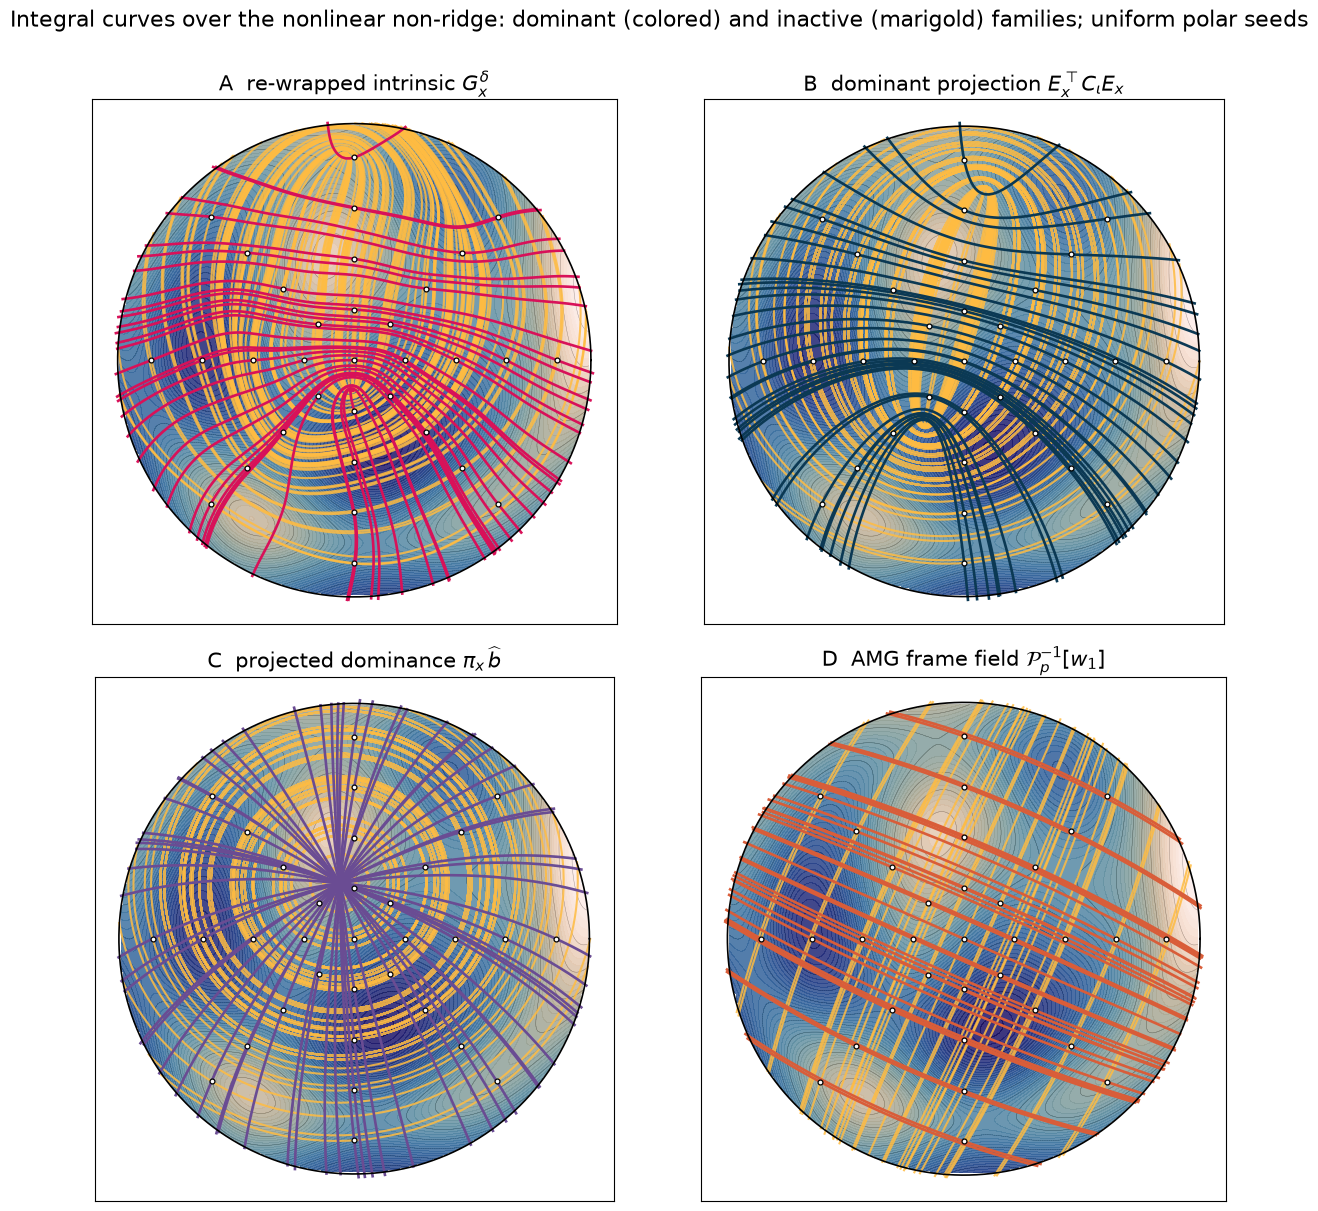

In [6]:
def to_chart(X):
    '''Log-map ambient curve points to the p0 normal-coordinate chart (E0).'''
    c = np.clip(X @ p0, -1, 1); d = np.arccos(c)
    s = np.sqrt(np.clip(1 - c**2, 0, None))
    V = np.where(s[:, None] > 1e-12,
                 (X - c[:, None] * p0) / np.where(s[:, None] > 1e-12, s[:, None], 1.0),
                 0.0)
    return d[:, None] * V @ E0

R_disp = 1.4
g = np.linspace(-R_disp, R_disp, 220)
T1, T2 = np.meshgrid(g, g)
tn = np.column_stack([T1.ravel(), T2.ravel()])
F = func.f(amg.sphere_exp_batch(p0, tn @ E0.T)).reshape(T1.shape)
F = np.where(np.hypot(T1, T2) <= R_disp, F, np.nan)

def draw_panel(ax, dom_curves, inact_curves, dom_color, title, mark_b=False):
    ax.contourf(T1, T2, F, 60, cmap=CMAP, alpha=0.85)
    ax.contour(T1, T2, F, 14, colors="k", linewidths=0.3, alpha=0.4)
    for cur in inact_curves:
        t = to_chart(cur)
        ax.plot(t[:, 0], t[:, 1], color=GEO["inactive"], lw=1.5, alpha=0.85)
    for cur in dom_curves:
        t = to_chart(cur)
        ax.plot(t[:, 0], t[:, 1], color=dom_color, lw=1.9)
    for s in seeds:
        t = to_chart(s[None, :])[0]
        ax.plot(*t, "o", ms=3.5, mfc="w", mec="k", mew=0.9, zorder=8)
    if mark_b:
        for bb in (b_hat, -b_hat):
            if np.arccos(np.clip(bb @ p0, -1, 1)) < R_disp:
                t = to_chart(bb[None, :])[0]
                ax.plot(*t, "x", ms=12, mew=3, color=GEO["embedding"], zorder=9)
    th_c = np.linspace(0, 2 * np.pi, 200)
    ax.plot(R_disp * np.cos(th_c), R_disp * np.sin(th_c), "k-", lw=1.2)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

DOMC = {"A": GEO["active"], "B": "#0B3954", "C": GEO["embedding"], "D": "#D95D39"}
fig, axes = plt.subplots(2, 2, figsize=(12.6, 12.2))
for ax, (lab, f) in zip(axes.ravel(), FIELDS.items()):
    key = lab.split()[0]
    draw_panel(ax, curves[(lab, -1)], curves[(lab, 0)], DOMC[key], lab,
               mark_b=(key == "C"))
fig.suptitle("Integral curves over the nonlinear non-ridge: dominant (colored) and "
             "inactive (marigold) families; uniform polar seeds", y=0.995)
fig.tight_layout()
fig.savefig("figs/integral_curves_chart.png", dpi=150, bbox_inches="tight")
plt.show()

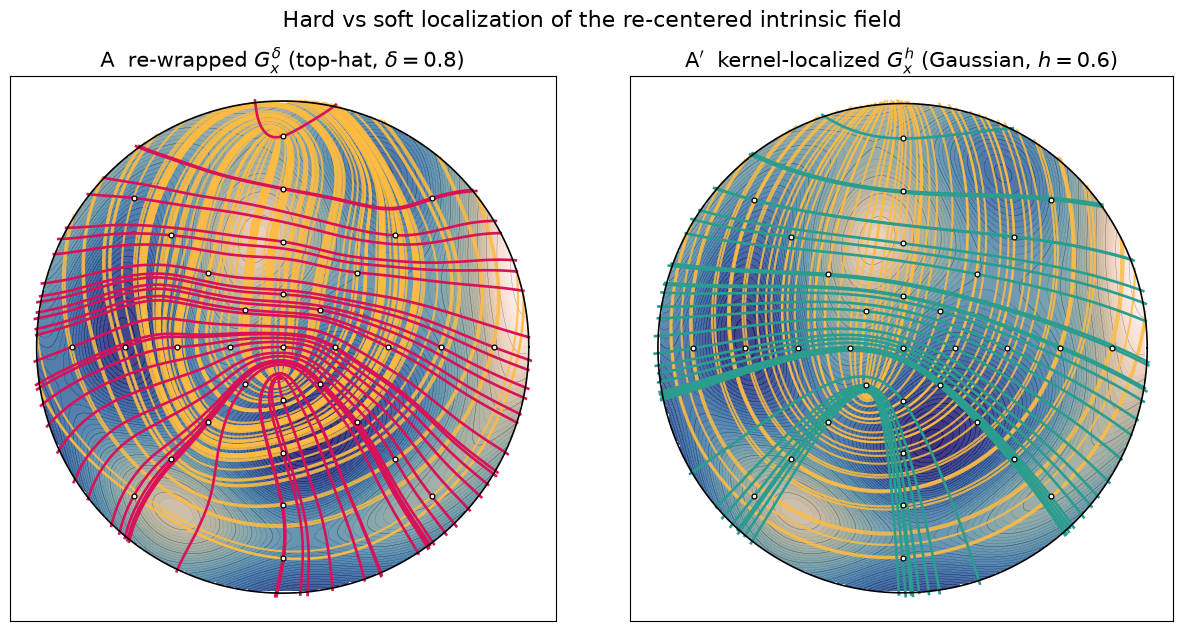

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 6.4))
draw_panel(axes[0], curves[(r"A  re-wrapped intrinsic $G_x^\delta$", -1)],
           curves[(r"A  re-wrapped intrinsic $G_x^\delta$", 0)], GEO["active"],
           r"A  re-wrapped $G_x^\delta$ (top-hat, $\delta=%.1f$)" % WRAP_DELTA)
draw_panel(axes[1], curves_K[-1], curves_K[0], "#2A9D8F",
           r"A$'$  kernel-localized $G_x^h$ (Gaussian, $h=%.1f$)" % KERNEL_H)
fig.suptitle("Hard vs soft localization of the re-centered intrinsic field", y=0.99)
fig.tight_layout()
fig.savefig("figs/integral_curves_localization.png", dpi=150, bbox_inches="tight")
plt.show()

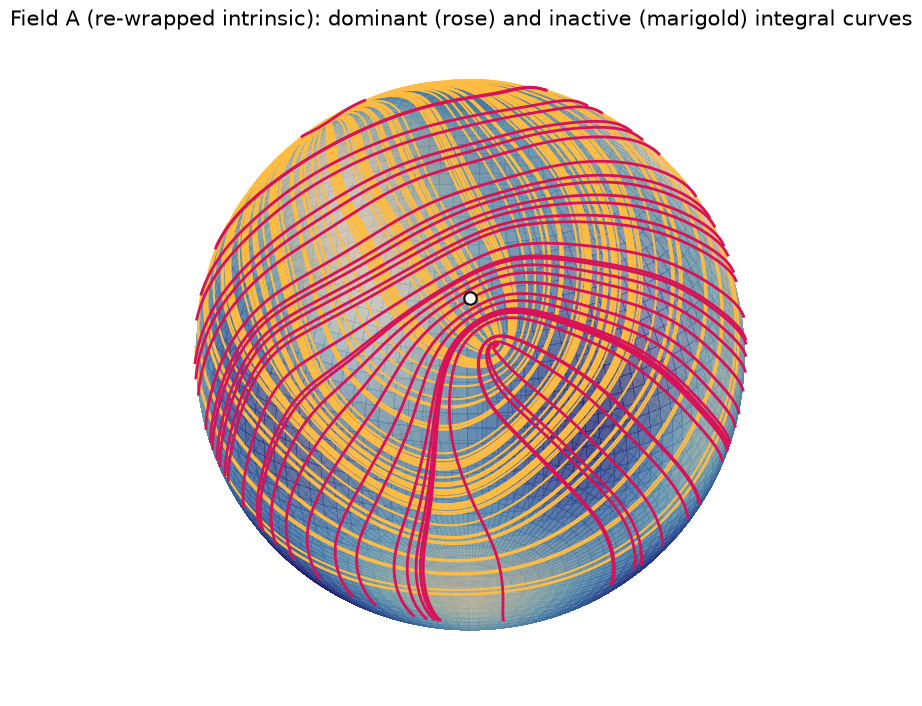

In [8]:
from sphere_amg_demo import _view_direction
elev, azim = 28, np.degrees(np.arctan2(p0[1], p0[0]))
fig = plt.figure(figsize=(9.5, 8.6))
ax = fig.add_subplot(111, projection="3d"); ax.computed_zorder = False
u = np.linspace(0, 2 * np.pi, 120); v = np.linspace(0, np.pi, 60)
XS = np.outer(np.cos(u), np.sin(v)); YS = np.outer(np.sin(u), np.sin(v))
ZS = np.outer(np.ones_like(u), np.cos(v))
FS = func.f(np.column_stack([XS.ravel(), YS.ravel(), ZS.ravel()])).reshape(XS.shape)
FSn = (FS - np.nanmin(FS)) / (np.nanmax(FS) - np.nanmin(FS))
ax.plot_surface(XS, YS, ZS, facecolors=CMAP(FSn), rstride=1, cstride=1,
                linewidth=0, antialiased=False, shade=False, alpha=0.55, zorder=0)
view = _view_direction(elev, azim)
for cur in curves[(r"A  re-wrapped intrinsic $G_x^\delta$", 0)]:
    near = (cur @ view) > 0.05
    ax.plot(*(cur[near] * 1.006).T, color=GEO["inactive"], lw=1.5, zorder=4)
for cur in curves[(r"A  re-wrapped intrinsic $G_x^\delta$", -1)]:
    near = (cur @ view) > 0.05
    ax.plot(*(cur[near] * 1.008).T, color=GEO["active"], lw=2.0, zorder=5)
ax.scatter(*(p0 * 1.02), color="w", s=80, edgecolor="k", lw=1.5, zorder=9)
ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
ax.view_init(elev=elev, azim=azim)
lim = 0.72
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_title("Field A (re-wrapped intrinsic): dominant (rose) and inactive "
             "(marigold) integral curves")
fig.savefig("figs/integral_curves_3d.png", dpi=150, bbox_inches="tight")
plt.show()

## Observations (v2: re-wrapped field, uniform polar seeds)

- **Local dominance is a different object than global dominance.** At $p_0$ the
  re-wrapped dominant direction ($\delta=0.8$) sits $21.6^\circ$ from the
  global-support $w_1$; the bandwidth is a modeling choice that selects *which*
  notion of activity the flow follows, interpolating between the pointwise
  gradient line ($\delta\to0$) and the global re-centered behavior
  ($\delta\to\infty$).
- **The trail system is robust to the localization mechanism.** Hard top-hat
  re-wrapping (A) and soft Gaussian kernel-localization (A$'$) produce
  strikingly consistent structures -- the same dominant sweep, the same fold
  below center, the same organization of the inactive family -- with A$'$
  smoother. (Bandwidths are not calibrated here: the Gaussian at $h=0.6$ over
  the $1.45$-cap carries more effective mass than the $\delta=0.8$ ball, which
  is why A$'$ sits closer to the global field at $p_0$, $3.6^\circ$ vs
  $21.6^\circ$. A matched-mass comparison is a next step.)
- **The local field carries richer singular structure.** The re-wrapped field
  shows more line-field degeneracies than the global re-centered version (the
  fold below center where dominant curves kink and the inactive family
  converges): localization sharpens response adaptation *and* multiplies the
  points where the local gap closes. These umbilics are structural
  (index-$\pm1/2$; Poincare--Hopf), not numerical artifacts.
- **The inactive family behaves like approximate leaves.** With uniform polar
  seeding, the marigold curves visibly organize along response bands (note the
  crowding along the high-$f$ ridge, upper region) -- consistent with reading
  the inactive flow as a local-foliation surrogate, though they are *not* level
  curves ($f$ is a non-ridge; compare the background contours).
- **B, C, D retain their characters**: B (fixed $C_\iota$, geometric
  compression only) bends similarly to the *global* re-centered field with its
  own degenerate points; C remains the great-circle pencil through
  $\pm\widehat{b}$, blind to the response; D remains the rigid coherent grid of
  the single central decomposition.
- **Not gradient flow.** The dominant field is the top eigenvector of an
  integrated second moment -- sign-free and variance-driven -- so trails cross
  level sets at varying angles and need not terminate at critical points.

**Next:** calibrate $h$ to $\delta$ (matched effective mass) and sweep the
bandwidth; color trails by the local gap $\eta(x)$ to expose the singular set;
repeat on the preferential quadratic (sanity: should organize around the
quadratic's tangential axis); variational characterization (principal-flows
analog) for existence/uniqueness through singularities; connect the inactive
family to the foliation remark (leaves as inactive flows).